# Visualizacion inicial de INbreast
Este notebook usa la funcion de `src` para listar y visualizar mamografias DICOM del dataset INbreast.

In [1]:
import sys
import random
import pydicom
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.visualization import list_dicom_images, show_dicom_image

## Laptop
DEFAULT_INBREAST_IMAGES_DIR = Path('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs')

## Definitions
BACKEND = 'np_v1'

In [2]:
print(DEFAULT_INBREAST_IMAGES_DIR)

/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs


In [3]:
dicom_paths = list_dicom_images(DEFAULT_INBREAST_IMAGES_DIR)

idx = random.randint(0, len(dicom_paths)-1)

print(f'Total de imagenes DICOM: {len(dicom_paths)}')
print(f'Imagen: {dicom_paths[idx].name}')
print(f'Index: {idx}')

Total de imagenes DICOM: 410
Imagen: 50998204_f34ee0ab6591b792_MG_R_ML_ANON.dcm
Index: 298


## Metadatos y preprocesado
Esta seccion muestra una mamografia tras aplicar windowing y segmentacion de fondo, junto con una superposicion de la mascara sobre la imagen original.

In [4]:
import matplotlib.pyplot as plt

from src.preprocessing import (
    apply_background_mask,
    # apply_windowing,
    load_dicom_pixels,
    read_dicom_metadata,
    segment_breast_region,
 )

from src.apply_windowing import *
from src.calculate_windowing import(
    get_dicom_voi_lut_params, 
    calculate_windowing, 
    should_invert_monochrome1, 
    normalize_photometric,
)


In [5]:
## Imagen de lista
image_path = list_dicom_images(DEFAULT_INBREAST_IMAGES_DIR)[idx]

### metadata <==> dcm
metadata = pydicom.dcmread(image_path)
print(metadata)

original_image = metadata.pixel_array

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 208
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.1.134384925412615473513893201090188098598
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.0.100.4.0
(0002,0013) Implementation Version Name         SH: 'MATLAB IPT 4.0'
-------------------------------------------------
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9590.100.1.1.134384925412615473513893201090188098598
(0008,0020) Study Date                          DA: ''
(0008,0023) Content Date                        DA: '20111229'
(0008,0030) Study Time      

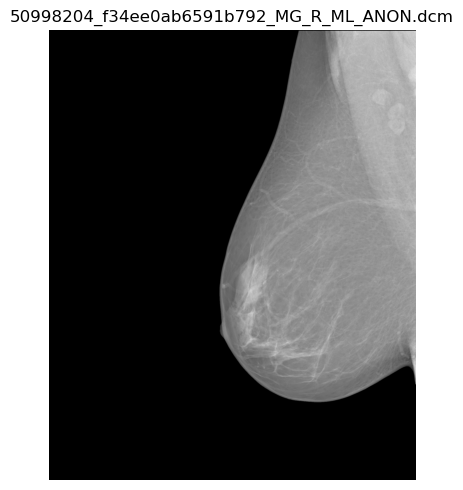

In [6]:
# figure, axis, image = show_dicom_image(image_index=idx)
figsize = (5, 5)

figure, axis = plt.subplots(figsize=figsize)
axis.imshow(original_image, cmap='gray')
axis.set_title(dicom_paths[idx].name)
axis.axis("off")
figure.tight_layout()

In [7]:
## Creo que normalize photometric ya hace la comprobación de si hay que invertir o no, pero por si acaso lo dejo
print(should_invert_monochrome1(metadata) )

if should_invert_monochrome1(metadata):
    original_image = normalize_photometric(original_image, metadata)

False


In [8]:

# Si no disponemos de una segmentación de la región de la mama, podemos aplicar un enmascaramiento de fondo 
# para eliminar el fondo antes de hacer el windowing. Esto es especialmente útil si la imagen tiene un fondo 
# muy brillante que puede afectar al contraste de la mama.

breast_mask = segment_breast_region(original_image)
processed_image = apply_background_mask(original_image, breast_mask)



In [9]:
## Windowing

# center, width = calculate_windowing(original_image) ## cambiar por 
voilut = get_dicom_voi_lut_params(metadata)
print(voilut)


# windowed_image = apply_windowing(load_dicom_pixels(image_path))
windowed_image = apply_windowing(original_image,
                                 window_width = voilut['window_width'],
                                 window_center = voilut['window_center'],
                                 voi_func = voilut['voi_lut_function'],
                                 y_min = original_image.min(),
                                 y_max =  original_image.max(), 
                                 backend = 'np_v2')

{'window_center': 1652, 'window_width': 828, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


(0008,0016): (0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018): (0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9590.100.1.1.134384925412615473513893201090188098598
(0008,0020): (0008,0020) Study Date                          DA: ''
(0008,0023): (0008,0023) Content Date                        DA: '20111229'
(0008,0030): (0008,0030) Study Time                          TM: ''
(0008,0033): (0008,0033) Content Time                        TM: '221011.452995'
(0008,0050): (0008,0050) Accession Number                    SH: ''
(0008,0060): (0008,0060) Modality                            CS: 'OT'
(0008,0064): (0008,0064) Conversion Type                     CS: 'WSD'
(0008,0090): (0008,0090) Referring Physician's Name          PN: ''
(0010,0010): (0010,0010) Patient's Name                      PN: ''
(0010,0020): (0010,0020) Patient ID                          LO: ''
(0010,0030): (0010,0030) Patient's Birth Date                DA: ''

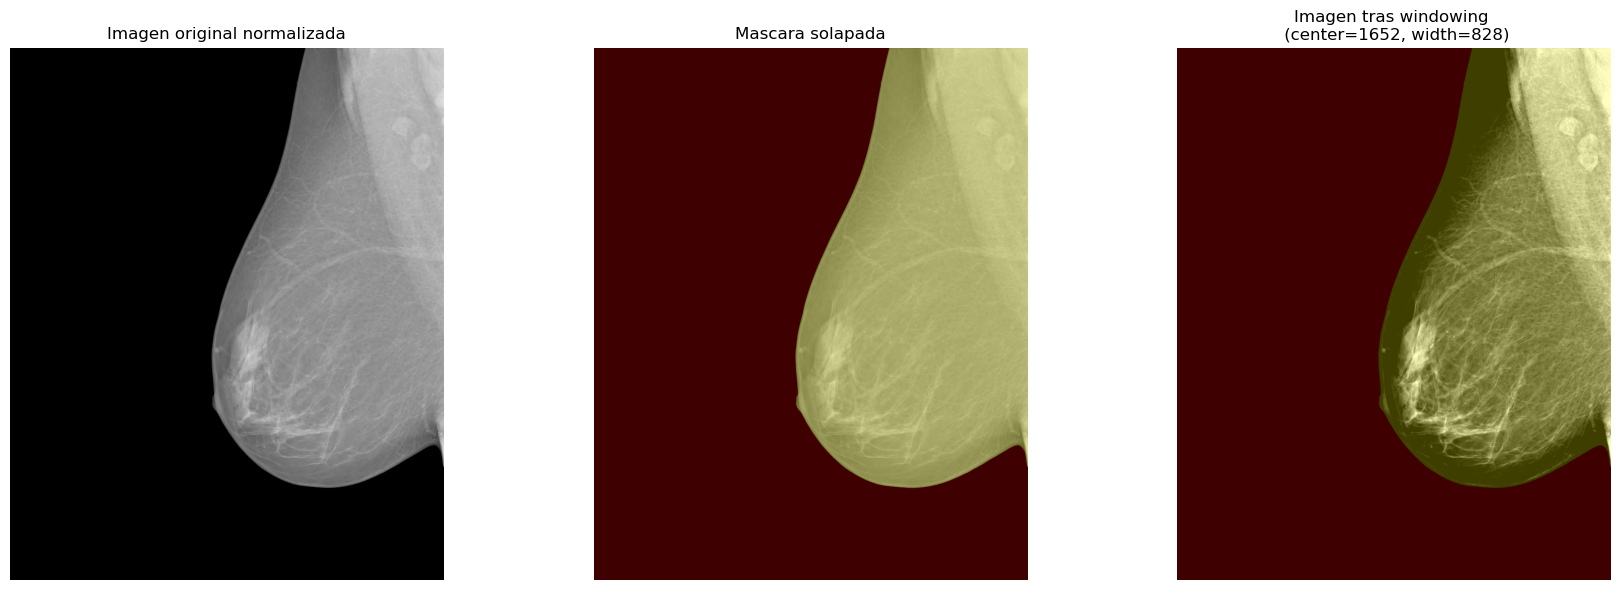

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original normalizada')
axes[0].axis('off')

axes[1].imshow(original_image, cmap='gray')
axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title('Mascara solapada')
axes[1].axis('off')

axes[2].imshow(windowed_image, cmap='gray')
axes[2].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[2].set_title(f'Imagen tras windowing \n (center={voilut["window_center"]}, width={voilut["window_width"]})')
axes[2].axis('off')

figure.tight_layout()

visible_metadata = {
    key: value
    for key, value in metadata.items()
    if value not in (None, '', [], {})
}

for key, value in visible_metadata.items():
    print(f'{key}: {value}')

## Incluir localización del pecho

In [11]:
import csv
import pandas as pd

INBREAST_CSV = Path('/home/eloygarcia/Escritorio/Datasets/INbreast/INBreast_breast_region.csv')

# Load CSV into a list of dicts
#with INBREAST_CSV.open(newline='', encoding='utf-8') as f:
#    records = list(csv.DictReader(f))
records = pd.read_csv(INBREAST_CSV)#.to_dict(orient='records')

print(f"Total annotations: {len(records)}")
print("Sample row:", records.iloc[0])

Total annotations: 410
Sample row: file_name    AllDICOMs/20586908_6c613a14b80a8591_MG_R_CC_AN...
bboxes       [1348.1292724609375, 34.610595703125, 3311.559...
scores                                                0.988837
Name: 0, dtype: object


In [12]:
import os

for index, row in records.iterrows():
    if os.path.basename(row['file_name']) == os.path.basename(image_path):
        print(f"Found annotation for {os.path.basename(row['file_name'])}: {row}")
        break

Found annotation for 50998204_f34ee0ab6591b792_MG_R_ML_ANON.dcm: file_name    AllDICOMs/50998204_f34ee0ab6591b792_MG_R_ML_AN...
bboxes       [1504.3831787109375, 321.6473083496094, 3306.9...
scores                                                0.985665
Name: 298, dtype: object


/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/50998204_f34ee0ab6591b792_MG_R_ML_ANON.dcm


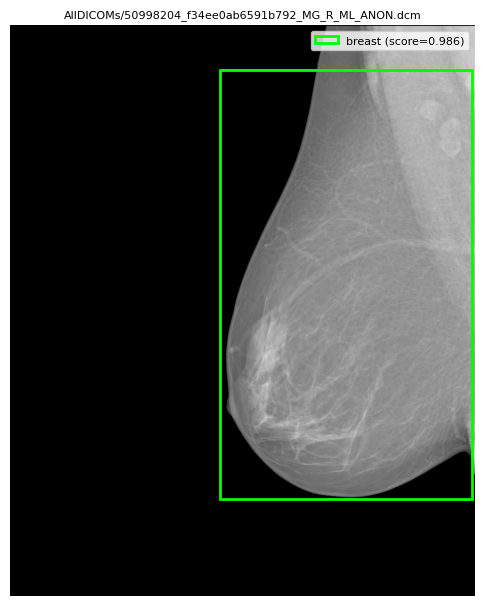

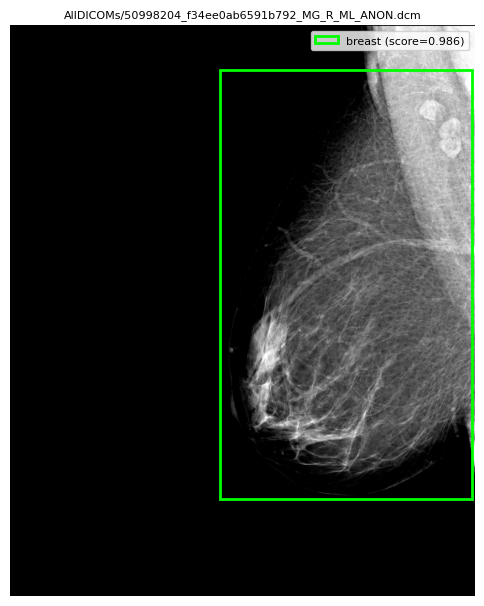

In [13]:
from src.visualization import show_dicom_with_bbox

print(image_path)

show_dicom_with_bbox(original_image, row)
#plt.tight_layout()
plt.show()

show_dicom_with_bbox(windowed_image, row)
#plt.tight_layout()
plt.show()


# Show a single random example
#record = random.choice(records)
#show_dicom_with_bbox(record)
#plt.tight_layout()
#plt.show()

## Mutliples ejemplos

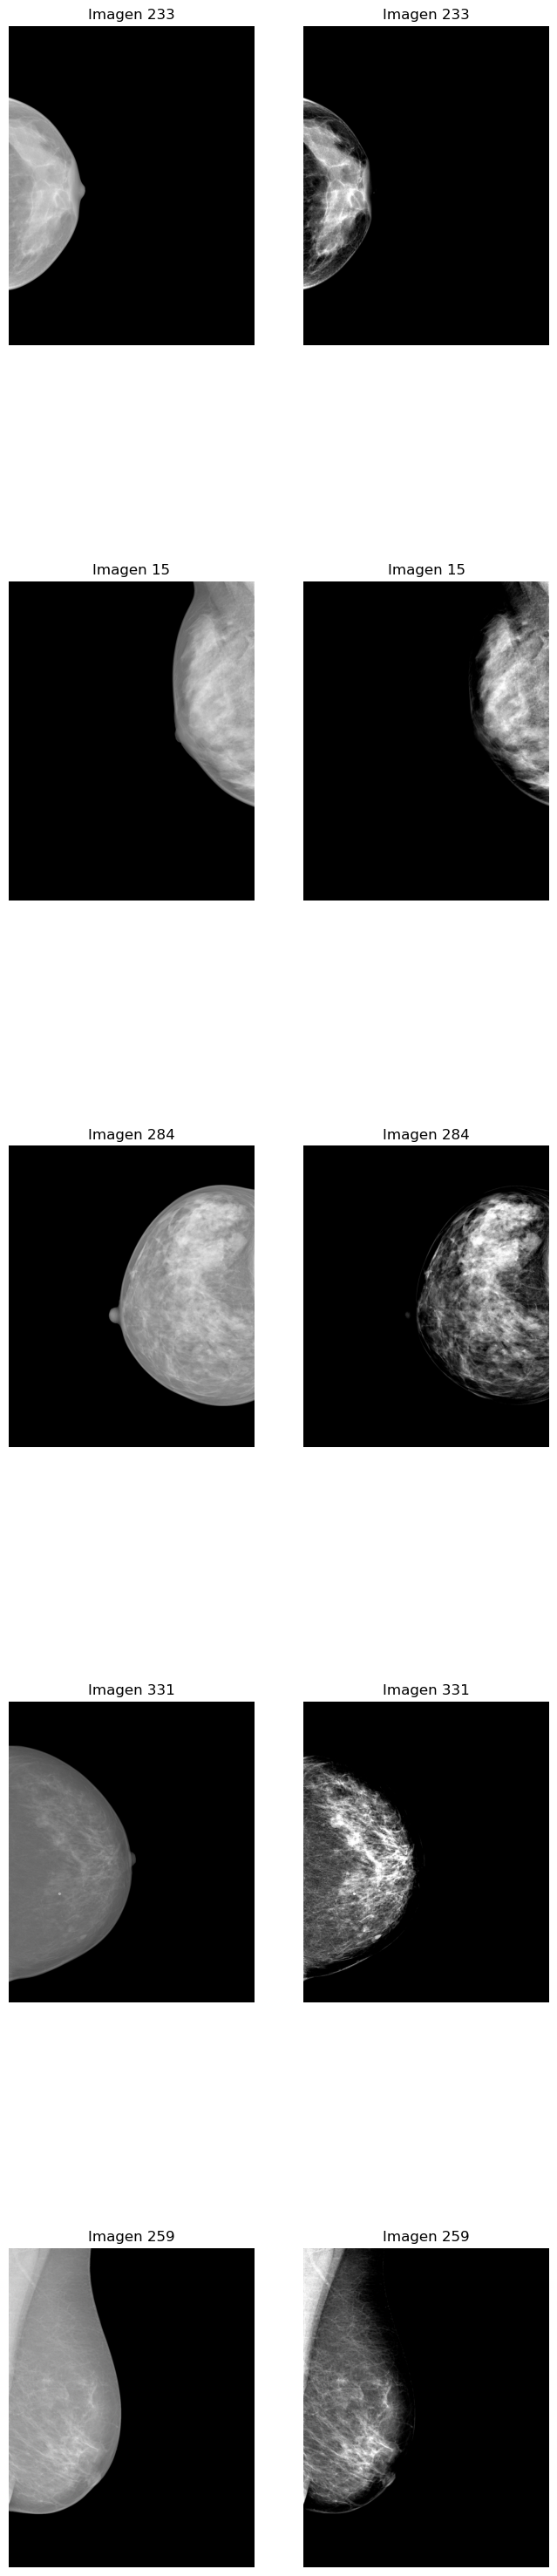

In [14]:
indexes = random.sample(range(len(dicom_paths)), 5)

figure, axes = plt.subplots(len(indexes),2, figsize=(8, 8*len(indexes)))
ct = 0 

for idx in indexes:
    image_path = dicom_paths[idx]

    metadata = pydicom.dcmread(image_path)
    original_image = metadata.pixel_array

    if should_invert_monochrome1(metadata):
        original_image = normalize_photometric(original_image, metadata)

    voilut = get_dicom_voi_lut_params(metadata)
    windowed_image = apply_windowing(original_image,
                                     window_width=voilut['window_width'],
                                     window_center=voilut['window_center'],
                                     voi_func=voilut['voi_lut_function'],
                                     y_min=original_image.min(),
                                     y_max=original_image.max(),
                                     backend='np_v2')

    breast_mask = segment_breast_region(original_image)


    axes[ct,0].imshow(original_image, cmap='gray')
    axes[ct,0].set_title(f'Imagen {idx}')
    axes[ct,0].axis('off')

    axes[ct,1].imshow(windowed_image, cmap='gray')
    #axes[ct,1].imshow(breast_mask, cmap='autumn', alpha=0.25)
    axes[ct,1].set_title(f'Imagen {idx}')
    axes[ct,1].axis('off')
    ct += 1


## Etiqueta pectoral en imagenes MLO
Esta seccion carga una imagen MLO con mascara pectoral disponible y genera una mascara etiquetada con tres clases: fondo, mama y musculo pectoral.

In [ ]:
import importlib

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import src.preprocessing as preprocessing
# from src.visualization import list_dicom_images

preprocessing = importlib.reload(preprocessing)

DEFAULT_PECTORAL_MASKS_DIR = Path("~/Escritorio/Datasets/INbreast/pectoral_masks").expanduser()

In [23]:
print(dicom_paths)
# print(list_dicom_images())

mlo_image_path = next(
    path
    for path in dicom_paths
    if '_ML_' in path.name and preprocessing.get_pectoral_mask_path(path)
 )

print(mlo_image_path)
mlo_image = preprocessing.load_dicom_pixels(mlo_image_path, normalize=True)
pectoral_mask = preprocessing.load_pectoral_mask(mlo_image_path)
labeled_mask = preprocessing.create_mlo_labeled_mask(mlo_image_path)

label_cmap = ListedColormap(['black', '#6dc36d', '#ffb347'])

[PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20586908_6c613a14b80a8591_MG_R_CC_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20586934_6c613a14b80a8591_MG_L_CC_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20586960_6c613a14b80a8591_MG_R_ML_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20586986_6c613a14b80a8591_MG_L_ML_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20587054_b6a4f750c6df4f90_MG_R_CC_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20587080_b6a4f750c6df4f90_MG_R_ML_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20587148_fd746d25eb40b3dc_MG_R_CC_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20587174_fd746d25eb40b3dc_MG_L_CC_ANON.dcm'), PosixPath('/home/eloygarcia/Escritorio/Datasets/INbreast/AllDICOMs/20587200_fd746d25eb40b3dc_MG

FileNotFoundError: Pectoral mask not found: /home/eloygarcia/Escritorio/Datasets/InBreast/pectoral_masks/20586960_mask.png

In [ ]:

figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(mlo_image, cmap='gray')
axes[0].set_title('Imagen MLO')
axes[0].axis('off')

axes[1].imshow(labeled_mask, cmap=label_cmap, vmin=0, vmax=2)
axes[1].set_title('Mascara etiquetada')
axes[1].axis('off')

axes[2].imshow(mlo_image, cmap='gray')
axes[2].imshow(labeled_mask == 2, cmap='autumn', alpha=0.35)
axes[2].set_title('Pectoral solapado')
axes[2].axis('off')

legend_handles = [
    Patch(facecolor='black', edgecolor='black', label='0: fondo'),
    Patch(facecolor='#6dc36d', edgecolor='#6dc36d', label='1: mama'),
    Patch(facecolor='#ffb347', edgecolor='#ffb347', label='2: pectoral'),
]
axes[1].legend(handles=legend_handles, loc='lower left', frameon=True)

figure.tight_layout()

print(f'Imagen MLO: {mlo_image_path.name}')
print(f'Mascara pectoral: {preprocessing.get_pectoral_mask_path(mlo_image_path).name}')
print(f'Etiquetas presentes: {sorted(set(labeled_mask.ravel().tolist()))}')

## Dataset de metadatos y comprobacion de dimensiones
Esta seccion carga el CSV de metadatos generado para INBreast y verifica que `Rows` y `Columns` coinciden con el tamano real de los arrays DICOM.

In [ ]:
import csv
from html import escape
from itertools import islice

from IPython.display import HTML, display

metadata_csv_path = Path('~/Escritorio/Datasets/InBreast/inbreast_image_metadata.csv').expanduser()

with metadata_csv_path.open(newline='', encoding='utf-8') as csv_file:
    metadata_rows = list(csv.DictReader(csv_file))

print(f'CSV de metadatos: {metadata_csv_path}')
print(f'Numero de imagenes registradas: {len(metadata_rows)}')

preview_columns = [
    'file_name',
    'laterality',
    'view_position',
    'rows',
    'columns',
    'pixel_spacing',
    'voi_lut_function',
    'window_center',
    'window_width',
    'windowing_source',
    'has_pectoral_mask',
]

preview_rows = list(islice(metadata_rows, 5))
table_header = ''.join(f'<th>{escape(column)}</th>' for column in preview_columns)
table_body = ''.join(
    '<tr>' + ''.join(f'<td>{escape(str(row.get(column, "")))}</td>' for column in preview_columns) + '</tr>'
    for row in preview_rows
)

display(HTML(
    '<table>'
    '<thead><tr>' + table_header + '</tr></thead>'
    '<tbody>' + table_body + '</tbody>'
    '</table>'
))

In [ ]:
from src.preprocessing import load_dicom_pixels

dimension_mismatches = []

for row in metadata_rows:
    image_array = load_dicom_pixels(row['image_path'])
    metadata_shape = (int(row['rows']), int(row['columns']))
    array_shape = tuple(int(value) for value in image_array.shape)

    if metadata_shape != array_shape:
        dimension_mismatches.append({
            'file_name': row['file_name'],
            'metadata_shape': metadata_shape,
            'array_shape': array_shape,
        })

print(f'Imagenes comprobadas: {len(metadata_rows)}')
print(f'Desajustes encontrados: {len(dimension_mismatches)}')

if dimension_mismatches:
    mismatch_columns = ['file_name', 'metadata_shape', 'array_shape']
    mismatch_header = ''.join(f'<th>{escape(column)}</th>' for column in mismatch_columns)
    mismatch_body = ''.join(
        '<tr>' + ''.join(f'<td>{escape(str(item[column]))}</td>' for column in mismatch_columns) + '</tr>'
        for item in dimension_mismatches[:10]
    )
    display(HTML(
        '<table>'
        '<thead><tr>' + mismatch_header + '</tr></thead>'
        '<tbody>' + mismatch_body + '</tbody>'
        '</table>'
))
else:
    print('Todas las dimensiones del CSV coinciden con las dimensiones de los arrays DICOM.')